# ทดสอบกับ dataset ภายนอก — PrintAksorn (ตัวพิมพ์จากฟอนต์)

ไฟล์นี้**รันได้อิสระ** ไม่พึ่ง `test_phet.ipynb` / `test_phet_v2.ipynb` / `test_phet_v3.ipynb`

**ขั้นที่ 1 (ไฟล์นี้ตอนนี้)**: สแกนโครงสร้าง `data/PrintAksorn_dataset/` อย่างเดียว — ยังไม่เขียน mapping หรือ inference

In [1]:
# 1.1 โครงสร้างโฟลเดอร์ + นามสกุลไฟล์
import csv, random, unicodedata
from collections import Counter, defaultdict
from pathlib import Path

PROJECT_ROOT = Path.cwd()
EXT_ROOT     = PROJECT_ROOT / "data" / "PrintAksorn_dataset"
IGNORE       = {".DS_Store"}

files = [p for p in EXT_ROOT.rglob("*") if p.is_file() and p.name not in IGNORE]
print(f"root: {EXT_ROOT.relative_to(PROJECT_ROOT)}")
print(f"ไฟล์ทั้งหมด (ไม่นับ .DS_Store) {len(files):,} | นามสกุล: {dict(Counter(p.suffix.lower() for p in files))}")

depth = Counter(len(p.relative_to(EXT_ROOT).parts) for p in files)
print(f"ความลึกของไฟล์ (จำนวนชั้นจาก root): {dict(depth)}   # 3 = <หมวด>/<คลาส>/<ไฟล์>, 1 = ไฟล์ที่ root")
print(f"ไฟล์ที่อยู่ root: {[p.name for p in files if len(p.relative_to(EXT_ROOT).parts) == 1]}")

groups = sorted(d for d in EXT_ROOT.iterdir() if d.is_dir())
print(f"\nชั้นที่ 1 = หมวดหมู่ ({len(groups)} หมวด):")
for g in groups:
    subs = sorted(x.name for x in g.iterdir() if x.is_dir())
    n = sum(1 for p in g.rglob("*.png"))
    print(f"  {g.name:<16} {len(subs):>3} โฟลเดอร์ย่อย · {n:>6,} ภาพ · เช่น {subs[:4]}")

root: data/PrintAksorn_dataset
ไฟล์ทั้งหมด (ไม่นับ .DS_Store) 38,571 | นามสกุล: {'.csv': 1, '.png': 38570}
ความลึกของไฟล์ (จำนวนชั้นจาก root): {1: 1, 3: 38570}   # 3 = <หมวด>/<คลาส>/<ไฟล์>, 1 = ไฟล์ที่ root
ไฟล์ที่อยู่ root: ['master_file.csv']

ชั้นที่ 1 = หมวดหมู่ (5 หมวด):
  consonants        44 โฟลเดอร์ย่อย · 17,864 ภาพ · เช่น ['bo_baimai', 'cho_chan', 'cho_chang', 'cho_ching']
  digits            10 โฟลเดอร์ย่อย ·  4,060 ภาพ · เช่น ['digit_0', 'digit_1', 'digit_2', 'digit_3']
  special_symbols   19 โฟลเดอร์ย่อย ·  7,714 ภาพ · เช่น ['baht', 'colon', 'comma', 'dot']
  tone_marks         5 โฟลเดอร์ย่อย ·  2,030 ภาพ · เช่น ['mai_chattawa', 'mai_ek', 'mai_tho', 'mai_tri']
  vowels            17 โฟลเดอร์ย่อย ·  6,902 ภาพ · เช่น ['lakkhangyao', 'maihan-akat', 'maitaikhu', 'sara_a']


In [2]:
# 1.2 ตัวอย่างชื่อไฟล์จากหลายโฟลเดอร์ย่อย
random.seed(0)
sub_dirs = [d for g in groups for d in g.iterdir() if d.is_dir()]
print(f"โฟลเดอร์คลาสทั้งหมด {len(sub_dirs)} โฟลเดอร์\n")
for d in random.sample(sub_dirs, 10):
    names = sorted(p.name for p in d.glob("*.png"))
    print(f"[{d.parent.name}/{d.name}]  {len(names)} ภาพ")
    for n in names[:2]: print(f"    {n}")

# ชื่อไฟล์ = <label>_<ชื่อฟอนต์>.png ?
ok = sum(1 for p in EXT_ROOT.rglob("*.png") if p.stem.startswith(p.parent.name + "_"))
print(f"\nไฟล์ที่ชื่อขึ้นต้นด้วย <ชื่อโฟลเดอร์>_ : {ok:,}/{sum(1 for _ in EXT_ROOT.rglob('*.png')):,}")

โฟลเดอร์คลาสทั้งหมด 95 โฟลเดอร์

[digits/digit_1]  406 ภาพ
    digit_1_Aksaramatee-Bold-Italic.png
    digit_1_Aksaramatee-Bold.png
[digits/digit_7]  406 ภาพ
    digit_7_Aksaramatee-Bold-Italic.png
    digit_7_Aksaramatee-Bold.png
[consonants/lo_ling]  406 ภาพ
    lo_ling_Aksaramatee-Bold-Italic.png
    lo_ling_Aksaramatee-Bold.png
[consonants/bo_baimai]  406 ภาพ
    bo_baimai_Aksaramatee-Bold-Italic.png
    bo_baimai_Aksaramatee-Bold.png
[special_symbols/slash]  406 ภาพ
    slash_Aksaramatee-Bold-Italic.png
    slash_Aksaramatee-Bold.png
[special_symbols/lbracket]  406 ภาพ
    lbracket_Aksaramatee-Bold-Italic.png
    lbracket_Aksaramatee-Bold.png
[digits/digit_9]  406 ภาพ
    digit_9_Aksaramatee-Bold-Italic.png
    digit_9_Aksaramatee-Bold.png
[consonants/cho_chan]  406 ภาพ
    cho_chan_Aksaramatee-Bold-Italic.png
    cho_chan_Aksaramatee-Bold.png
[special_symbols/exclamation]  406 ภาพ
    exclamation_Aksaramatee-Bold-Italic.png
    exclamation_Aksaramatee-Bold.png
[digits/digit_5]  4

In [3]:
# 1.3 ไฟล์ metadata: master_file.csv
csv_path = EXT_ROOT / "master_file.csv"
rows = list(csv.DictReader(open(csv_path, encoding="utf-8")))
print(f"{csv_path.name}: {len(rows):,} แถว · คอลัมน์ {list(rows[0])}\n")
for r in rows[:3]: print("   ", r)

png_paths = {p.relative_to(EXT_ROOT).as_posix() for p in EXT_ROOT.rglob("*.png")}
csv_paths = {r["filepath"] for r in rows}
print(f"\nไฟล์ .png จริง {len(png_paths):,} | แถวใน CSV {len(csv_paths):,} | "
      f"CSV ชี้ไปไฟล์ที่ไม่มี {len(csv_paths - png_paths)} | ไฟล์ที่ไม่มีใน CSV {len(png_paths - csv_paths)}")

# label อยู่ตรงไหน: ชื่อโฟลเดอร์ (โรมัน) / คอลัมน์ original_character (Unicode ตรงๆ)
mismatch = [r for r in rows if Path(r["filepath"]).parent.name != r["label"]]
print(f"แถวที่ label ไม่ตรงกับชื่อโฟลเดอร์: {len(mismatch)}")
chars = {r["original_character"] for r in rows}
print(f"ตัวอักษรไม่ซ้ำในคอลัมน์ original_character: {len(chars)} ตัว (เป็น Unicode ตรงๆ ไม่ใช่รหัสตัวเลข)")
print("ตัวอย่าง:", [(r["label"], r["original_character"], f"U+{ord(r['original_character']):04X}") for r in rows[:5]])

master_file.csv: 38,570 แถว · คอลัมน์ ['filepath', 'original_character', 'label', 'category', 'font_name']

    {'filepath': 'consonants/ko_kai/ko_kai_Prompt-ThinItalic.png', 'original_character': 'ก', 'label': 'ko_kai', 'category': 'consonants', 'font_name': 'Prompt-ThinItalic'}
    {'filepath': 'consonants/ko_kai/ko_kai_NotoSerifThai-ExtraCondensedBlack.png', 'original_character': 'ก', 'label': 'ko_kai', 'category': 'consonants', 'font_name': 'NotoSerifThai-ExtraCondensedBlack'}
    {'filepath': 'consonants/ko_kai/ko_kai_Kanit-ExtraLight.png', 'original_character': 'ก', 'label': 'ko_kai', 'category': 'consonants', 'font_name': 'Kanit-ExtraLight'}

ไฟล์ .png จริง 38,570 | แถวใน CSV 38,570 | CSV ชี้ไปไฟล์ที่ไม่มี 0 | ไฟล์ที่ไม่มีใน CSV 0
แถวที่ label ไม่ตรงกับชื่อโฟลเดอร์: 0
ตัวอักษรไม่ซ้ำในคอลัมน์ original_character: 95 ตัว (เป็น Unicode ตรงๆ ไม่ใช่รหัสตัวเลข)
ตัวอย่าง: [('ko_kai', 'ก', 'U+0E01'), ('ko_kai', 'ก', 'U+0E01'), ('ko_kai', 'ก', 'U+0E01'), ('ko_kai', 'ก', 'U+0E01'), ('ko_ka

In [4]:
# 1.4 จำนวนคลาส / ภาพต่อคลาส / ฟอนต์
per_class = Counter((r["category"], r["label"]) for r in rows)
fonts     = Counter(r["font_name"] for r in rows)
print(f"คลาสทั้งหมด {len(per_class)} คลาส | ภาพต่อคลาส min {min(per_class.values())} max {max(per_class.values())}")
print(f"ฟอนต์ {len(fonts)} แบบ | ภาพต่อฟอนต์ min {min(fonts.values())} max {max(fonts.values())}")
print(f"-> {len(per_class)} คลาส × {len(fonts)} ฟอนต์ = {len(per_class) * len(fonts):,} ภาพ\n")

for cat in ["consonants", "vowels", "tone_marks", "digits", "special_symbols"]:
    items = sorted({(r["label"], r["original_character"]) for r in rows if r["category"] == cat})
    print(f"{cat} ({len(items)}): " + " ".join(ch for _, ch in items))

print("\nspecial_symbols แต่ละตัว:")
for l, ch in sorted({(r["label"], r["original_character"]) for r in rows if r["category"] == "special_symbols"}):
    print(f"  {l:<12} {ch!r}  U+{ord(ch):04X}  {unicodedata.name(ch, '?')}")

คลาสทั้งหมด 95 คลาส | ภาพต่อคลาส min 406 max 406
ฟอนต์ 406 แบบ | ภาพต่อฟอนต์ min 95 max 95
-> 95 คลาส × 406 ฟอนต์ = 38,570 ภาพ

consonants (44): บ จ ช ฉ ฌ ฎ ด ฝ ฟ ห ฮ ข ฅ ฃ ค ฆ ก ฬ ล ม ง ณ น อ พ ผ ภ ป ร ษ ศ ซ ส ฑ ฒ ท ฐ ธ ถ ฏ ต ว ย ญ
vowels (17): ๅ ั ็ ะ า แ ไ ใ ำ เ ิ ี โ ุ ึ ื ู
tone_marks (5): ๋ ่ ้ ๊ ์
digits (10): ๐ ๑ ๒ ๓ ๔ ๕ ๖ ๗ ๘ ๙
special_symbols (19): ฿ : , . ! { [ ( ๆ — – ฯ ? " } ] ) ; /

special_symbols แต่ละตัว:
  baht         '฿'  U+0E3F  THAI CURRENCY SYMBOL BAHT
  colon        ':'  U+003A  COLON
  comma        ','  U+002C  COMMA
  dot          '.'  U+002E  FULL STOP
  exclamation  '!'  U+0021  EXCLAMATION MARK
  lbrace       '{'  U+007B  LEFT CURLY BRACKET
  lbracket     '['  U+005B  LEFT SQUARE BRACKET
  lparen       '('  U+0028  LEFT PARENTHESIS
  maiyamok     'ๆ'  U+0E46  THAI CHARACTER MAIYAMOK
  mdash        '—'  U+2014  EM DASH
  ndash        '–'  U+2013  EN DASH
  paiyannoi    'ฯ'  U+0E2F  THAI CHARACTER PAIYANNOI
  question     '?'  U+003F  QUESTION MARK
  quote   

In [5]:
# 1.5 เทียบกับ 81 คลาสของโปรเจกต์เรา (สแกน data/character, data/number ใหม่ ไม่พึ่ง notebook อื่น)
our_codes = sorted({int(p.parent.parent.name)
                    for top in ["character", "number"]
                    for p in (PROJECT_ROOT / "data" / top).glob("*/D*/*")
                    if p.is_file() and p.name not in IGNORE})
ours = {bytes([c]).decode("tis-620"): c for c in our_codes}

inter = sorted(set(ours) & chars, key=lambda ch: ours[ch])
only_ours = sorted(set(ours) - chars, key=lambda ch: ours[ch])
only_ext  = sorted(chars - set(ours))
print(f"คลาสเรา {len(ours)} | PrintAksorn {len(chars)} | ตรงกัน {len(inter)}")
print(f"เรามี แต่ PrintAksorn ไม่มี ({len(only_ours)}): " + " ".join(f"{ch} ({ours[ch]})" for ch in only_ours))
print(f"PrintAksorn มี แต่เราไม่มี ({len(only_ext)}): " + " ".join(only_ext))

# PrintAksorn เก็บ label เป็น Unicode ตรงๆ ส่วนของเราเป็นเลขโฟลเดอร์ TIS-620 -> แปลงหากันได้ด้วย encode/decode
def tis_code(ch):
    try: return ch.encode("tis-620")[0]
    except UnicodeEncodeError: return None
enc = {ch: tis_code(ch) for ch in sorted(chars)}
print(f"\nตัวอักษร PrintAksorn ที่เข้ารหัส TIS-620 ได้: {sum(v is not None for v in enc.values())}/{len(enc)}"
      f" | เข้ารหัสไม่ได้: {[ch for ch, v in enc.items() if v is None]}")

คลาสเรา 81 | PrintAksorn 95 | ตรงกัน 78
เรามี แต่ PrintAksorn ไม่มี (3): ฤ (196) ฦ (198) ํ (237)
PrintAksorn มี แต่เราไม่มี (17): ! " ( ) , . / : ; ? [ ] { } ฿ – —

ตัวอักษร PrintAksorn ที่เข้ารหัส TIS-620 ได้: 93/95 | เข้ารหัสไม่ได้: ['–', '—']


In [6]:
# 1.6 คุณสมบัติภาพ (สุ่ม 200 ภาพ)
from PIL import Image
import numpy as np

sample = random.sample(rows, 200)
sizes, modes, means = Counter(), Counter(), []
for r in sample:
    with Image.open(EXT_ROOT / r["filepath"]) as im:
        sizes[im.size] += 1; modes[im.mode] += 1
        means.append(np.asarray(im.convert("L"), dtype=np.float32).mean())
means = np.array(means)
print(f"ขนาด: {sizes.most_common(3)} | mode: {dict(modes)}")
print(f"mean brightness: median {np.median(means):.0f} (min {means.min():.0f} max {means.max():.0f}) | "
      f"สัดส่วนภาพพื้นมืด (mean<128): {np.mean(means < 128):.0%}  -> หมึกเข้มบนพื้นสว่าง เหมือน dataset ของเรา")

ขนาด: [((224, 224), 200)] | mode: {'RGB': 200}
mean brightness: median 251 (min 237 max 255) | สัดส่วนภาพพื้นมืด (mean<128): 0%  -> หมึกเข้มบนพื้นสว่าง เหมือน dataset ของเรา


## ขั้นที่ 2 — ทดสอบโมเดล v1 (`best_resnet50.pt`) กับ PrintAksorn
ทดสอบเฉพาะ **78 คลาสที่ตรงกัน** (ข้าม ฤ ฦ ํ ที่ PrintAksorn ไม่มี และสัญลักษณ์ 17 ตัวที่โมเดลเราไม่รู้จัก)
label ได้จาก `original_character` → TIS-620 → unified index ของเราโดยตรง ไม่ผ่านชื่อโฟลเดอร์แบบโรมัน
ผลบันทึกลง `external_test_printaksorn/` (โฟลเดอร์ใหม่ ไม่ปนกับ `outputs/`)

In [7]:
# 2.1 Setup + โหลด checkpoint v1
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet50
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np

RESULT_DIR = PROJECT_ROOT / "external_test_printaksorn"; RESULT_DIR.mkdir(exist_ok=True)
CKPT_PATH  = PROJECT_ROOT / "checkpoints" / "best_resnet50.pt"
device = "mps" if torch.backends.mps.is_available() else "cpu"
for f in ["/System/Library/Fonts/Supplemental/Ayuthaya.ttf", "/System/Library/Fonts/Thonburi.ttc"]:
    if Path(f).exists():
        font_manager.fontManager.addfont(f); plt.rcParams["font.family"] = font_manager.FontProperties(fname=f).get_name(); break

ckpt = torch.load(CKPT_PATH, map_location=device)
IDX_TO_CHAR = ckpt["idx_to_char"]
CHAR_TO_IDX = {ch: i for i, ch in enumerate(IDX_TO_CHAR)}      # ย้อนกลับ
NUM_CLASSES = ckpt["num_classes"]
TARGET, INPUT_SIZE = ckpt["target"], ckpt["input_size"]
GRAY_MEAN, GRAY_STD = ckpt["gray_mean"], ckpt["gray_std"]
MARGIN = 4                                                     # ค่าเดิมจาก test_phet.ipynb
print(f"checkpoint: epoch {ckpt['epoch']} · val acc {ckpt['val_acc']:.4f} · val macro F1 {ckpt['val_f1']:.4f}")
print(f"{NUM_CLASSES} คลาส · target {TARGET} · input {INPUT_SIZE} · normalize ({GRAY_MEAN}, {GRAY_STD}) · device {device}")

checkpoint: epoch 13 · val acc 0.9715 · val macro F1 0.9671
81 คลาส · target 64 · input 128 · normalize (0.449, 0.226) · device mps


In [8]:
# 2.2 Preprocessing — คัดลอกจาก test_phet.ipynb ทุกค่าพารามิเตอร์ ห้ามแก้
import cv2
from PIL import Image
from skimage.filters import threshold_sauvola
from skimage.measure import label as cc_label

def load_gray(path) -> np.ndarray:
    with Image.open(path) as im:
        return np.asarray(im.convert("L"), dtype=np.uint8)

def border_dark_fraction(g: np.ndarray) -> float:
    return float((np.concatenate([g[0], g[-1], g[:, 0], g[:, -1]]) < 128).mean())

def normalize_polarity(g: np.ndarray) -> np.ndarray:
    if int(g.max()) - int(g.min()) < 30: return g
    return 255 - g if border_dark_fraction(g) >= 0.97 else g

def sauvola_binarize(g: np.ndarray, k: float = 0.2) -> np.ndarray:
    if int(g.max()) - int(g.min()) < 30:
        return np.full(g.shape, g.mean() < 128)
    h, w = g.shape
    win = max(3, min(25, (min(h, w) // 2) | 1))
    t = threshold_sauvola(g, window_size=win, k=k)
    bg = float(np.percentile(g, 99))
    ink = ((g < t) | (g < 0.5 * bg)) & (g < bg - 30)
    lab = cc_label(ink, connectivity=2)
    if lab.max() > 1:
        areas = np.bincount(lab.ravel()); areas[0] = 0
        ink = np.isin(lab, np.flatnonzero(areas >= 0.01 * areas.sum()))
    return ink

def tight_crop(mask: np.ndarray) -> np.ndarray:
    ys, xs = np.nonzero(mask)
    if len(ys) == 0: return mask
    return mask[ys.min():ys.max() + 1, xs.min():xs.max() + 1]

def resize_keep_aspect(mask: np.ndarray, box: int = TARGET - 2 * MARGIN) -> np.ndarray:
    h, w = mask.shape
    s = box / max(h, w)
    nh, nw = max(1, round(h * s)), max(1, round(w * s))
    interp = cv2.INTER_AREA if s < 1 else cv2.INTER_LINEAR
    return cv2.resize(mask.astype(np.uint8) * 255, (nw, nh), interpolation=interp)

def letterbox_centroid(glyph: np.ndarray, size: int = TARGET) -> np.ndarray:
    h, w = glyph.shape
    m = cv2.moments(glyph, binaryImage=False)
    cy, cx = (m["m01"] / m["m00"], m["m10"] / m["m00"]) if m["m00"] > 0 else (h / 2, w / 2)
    top  = int(np.clip(round(size / 2 - cy), 0, size - h))
    left = int(np.clip(round(size / 2 - cx), 0, size - w))
    canvas = np.zeros((size, size), np.uint8)
    canvas[top:top + h, left:left + w] = glyph
    return canvas

def preprocess(path) -> np.ndarray:
    return letterbox_centroid(resize_keep_aspect(tight_crop(sauvola_binarize(normalize_polarity(load_gray(path))))))

_t = preprocess(EXT_ROOT / rows[0]["filepath"])
print(f"ตรวจ: {rows[0]['filepath']} -> {_t.shape} {_t.dtype} max {_t.max()}")

ตรวจ: consonants/ko_kai/ko_kai_Prompt-ThinItalic.png -> (64, 64) uint8 max 255


In [9]:
# 2.3 กรองเฉพาะ 78 คลาสที่ตรงกัน — label มาจาก original_character -> TIS-620 -> index ของเรา
def tis_code(ch):
    try: return ch.encode("tis-620")[0]
    except UnicodeEncodeError: return None

test_rows, skipped = [], Counter()
for r in rows:
    ch = r["original_character"]
    code = tis_code(ch)
    if code is None or ch not in CHAR_TO_IDX:
        skipped[ch] += 1; continue
    test_rows.append({**r, "label_idx": CHAR_TO_IDX[ch], "char": ch})

test_classes = sorted({r["label_idx"] for r in test_rows})
print(f"ใช้ทดสอบ {len(test_rows):,} ภาพ · {len(test_classes)} คลาส")
print(f"ข้าม {sum(skipped.values()):,} ภาพ · {len(skipped)} คลาส -> {' '.join(sorted(skipped))}")
print(f"ภาพต่อคลาส: {sorted(Counter(r['label_idx'] for r in test_rows).values())[:3]} ... (ควรเท่ากันหมด = 406)")

ใช้ทดสอบ 31,668 ภาพ · 78 คลาส
ข้าม 6,902 ภาพ · 17 คลาส -> ! " ( ) , . / : ; ? [ ] { } ฿ – —
ภาพต่อคลาส: [406, 406, 406] ... (ควรเท่ากันหมด = 406)


In [10]:
# 2.4 โครงสร้างโมเดล (คัดลอกเฉพาะ class definition จาก test_phet.ipynb) + โหลด weight
class ThaiHCRNet(nn.Module):
    def __init__(self, num_classes, input_size=INPUT_SIZE, pretrained=False):
        super().__init__()
        net = resnet50(weights=None)                       # ไม่ต้องโหลด ImageNet เพราะจะทับด้วย state_dict อยู่แล้ว
        old = net.conv1
        net.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        with torch.no_grad():
            net.conv1.weight.copy_(old.weight.sum(dim=1, keepdim=True))
        net.fc = nn.Linear(net.fc.in_features, num_classes)
        self.net, self.input_size = net, input_size
    def forward(self, x):
        if x.shape[-1] != self.input_size:
            x = F.interpolate(x, size=(self.input_size, self.input_size), mode="bilinear", align_corners=False)
        return self.net(x)

model = ThaiHCRNet(NUM_CLASSES).to(device)
model.load_state_dict(ckpt["model_state"], strict=True)
model.eval()
print("โหลด weight สำเร็จ (strict=True) · model.eval()")

โหลด weight สำเร็จ (strict=True) · model.eval()


In [11]:
# 2.5 Inference กับทุกภาพที่กรองไว้
import time

X_CACHE = np.zeros((len(test_rows), TARGET, TARGET), dtype=np.uint8)   # เก็บผล preprocess ไว้ใช้ซ้ำกับโมเดลตัวอื่น
Y_TRUE  = np.array([r["label_idx"] for r in test_rows])

class ExternalDataset(Dataset):
    """preprocess() ตอน __getitem__ แล้วเก็บลง X_CACHE (num_workers=0 จึงเขียนใน process เดียวกัน ปลอดภัย)"""
    def __init__(self, items): self.items = items
    def __len__(self): return len(self.items)
    def __getitem__(self, i):
        r = self.items[i]
        raw = preprocess(EXT_ROOT / r["filepath"])
        X_CACHE[i] = raw
        img = torch.from_numpy(raw).unsqueeze(0).float() / 255.0
        return (img - GRAY_MEAN) / GRAY_STD, r["label_idx"]

loader = DataLoader(ExternalDataset(test_rows), batch_size=128, shuffle=False, num_workers=0)   # 0 = เสถียรสุดบน Mac
t0 = time.perf_counter()
y_true, y_pred = [], []
with torch.no_grad():
    for bi, (x, y) in enumerate(loader):
        with torch.autocast(device_type=device, dtype=torch.bfloat16, enabled=True):
            logits = model(x.to(device))
        y_true.append(y); y_pred.append(logits.argmax(1).cpu())
        if bi % 50 == 0: print(f"  batch {bi}/{len(loader)} ({time.perf_counter() - t0:.0f}s)", flush=True)
y_true = torch.cat(y_true).numpy(); y_pred = torch.cat(y_pred).numpy()
print(f"เสร็จ {len(y_true):,} ภาพ ใน {time.perf_counter() - t0:.0f}s | "
      f"X_CACHE {X_CACHE.shape} {X_CACHE.nbytes / 1e6:.0f} MB (ใช้ซ้ำกับ v3 ได้ ไม่ต้อง preprocess ใหม่)")
assert (Y_TRUE == y_true).all(), "ลำดับ label ไม่ตรงกับ X_CACHE"

  batch 0/248 (1s)
  batch 50/248 (27s)
  batch 100/248 (52s)
  batch 150/248 (78s)
  batch 200/248 (103s)
เสร็จ 31,668 ภาพ ใน 127s | X_CACHE (31668, 64, 64) 130 MB (ใช้ซ้ำกับ v3 ได้ ไม่ต้อง preprocess ใหม่)


In [12]:
# 2.6 ผลระดับที่ 1 — ภาพรวม เทียบกับผลบน validation ของเรา
acc = float((y_true == y_pred).mean())
f1  = f1_score(y_true, y_pred, average="macro", labels=test_classes, zero_division=0)
print(f"{'ชุดข้อมูล':<42}{'ภาพ':>9}{'คลาส':>7}{'accuracy':>11}{'macro F1':>11}")
print(f"{'PrintAksorn (ตัวพิมพ์ 406 ฟอนต์)':<42}{len(y_true):>9,}{len(test_classes):>7}{acc:>11.4f}{f1:>11.4f}")
print(f"{'— val เดิมของ v1 (ทั้ง 3 source)':<42}{32656:>9,}{81:>7}{0.9715:>11.4f}{0.9671:>11.4f}")
print(f"{'— val เดิม เฉพาะ D1 (ตัวพิมพ์)':<42}{12484:>9,}{72:>7}{0.9897:>11.4f}{0.9332:>11.4f}")
print(f"\nต่างจาก val ทั้งหมด: accuracy {acc - 0.9715:+.4f} · macro F1 {f1 - 0.9671:+.4f}")
print(f"ต่างจาก val เฉพาะ D1 : accuracy {acc - 0.9897:+.4f} · macro F1 {f1 - 0.9332:+.4f}")

ชุดข้อมูล                                       ภาพ   คลาส   accuracy   macro F1
PrintAksorn (ตัวพิมพ์ 406 ฟอนต์)             31,668     78     0.8594     0.8588
— val เดิมของ v1 (ทั้ง 3 source)             32,656     81     0.9715     0.9671
— val เดิม เฉพาะ D1 (ตัวพิมพ์)               12,484     72     0.9897     0.9332

ต่างจาก val ทั้งหมด: accuracy -0.1121 · macro F1 -0.1083
ต่างจาก val เฉพาะ D1 : accuracy -0.1303 · macro F1 -0.0744


In [13]:
# 2.7 ผลระดับที่ 2 — แยกตามหมวด
cat_of = np.array([r["category"] for r in test_rows])
cat_rows = []
for cat in ["consonants", "vowels", "tone_marks", "digits"]:
    m = cat_of == cat
    if not m.any(): continue
    yt, yp = y_true[m], y_pred[m]
    present = sorted(set(yt.tolist()))
    cat_rows.append({"category": cat, "n_images": int(m.sum()), "n_classes": len(present),
                     "accuracy": round(float((yt == yp).mean()), 4),
                     "macro_f1": round(f1_score(yt, yp, average="macro", labels=present, zero_division=0), 4)})
cat_rows.append({"category": "ALL", "n_images": len(y_true), "n_classes": len(test_classes),
                 "accuracy": round(acc, 4), "macro_f1": round(f1, 4)})
print(f"{'หมวด':<16}{'ภาพ':>9}{'คลาส':>7}{'accuracy':>11}{'macro F1':>11}")
for r in cat_rows:
    print(f"{r['category']:<16}{r['n_images']:>9,}{r['n_classes']:>7}{r['accuracy']:>11.4f}{r['macro_f1']:>11.4f}")

หมวด                  ภาพ   คลาส   accuracy   macro F1
consonants         17,864     44     0.8949     0.9033
vowels              6,902     17     0.8254     0.8607
tone_marks          2,030      5     0.8788     0.9272
digits              4,060     10     0.7421     0.7979
ALL                31,668     78     0.8594     0.8588


In [14]:
# 2.8 ผลระดับที่ 3 — แยกตามฟอนต์ (406 ฟอนต์)
font_of = np.array([r["font_name"] for r in test_rows])
font_rows = []
for fname in sorted(set(font_of)):
    m = font_of == fname
    font_rows.append({"font_name": fname, "n_images": int(m.sum()),
                      "accuracy": round(float((y_true[m] == y_pred[m]).mean()), 4)})
font_rows.sort(key=lambda r: r["accuracy"])
accs = np.array([r["accuracy"] for r in font_rows])
print(f"ฟอนต์ {len(font_rows)} แบบ · accuracy เฉลี่ย {accs.mean():.4f} · median {np.median(accs):.4f} · "
      f"ช่วง {accs.min():.4f}–{accs.max():.4f}\n")
print("10 ฟอนต์ที่แย่ที่สุด" + " " * 26 + "| 10 ฟอนต์ที่ดีที่สุด")
best = font_rows[::-1][:10]
for lo, hi in zip(font_rows[:10], best):
    print(f"  {lo['font_name'][:34]:<36}{lo['accuracy']:.4f} |   {hi['font_name'][:34]:<36}{hi['accuracy']:.4f}")

ฟอนต์ 406 แบบ · accuracy เฉลี่ย 0.8594 · median 0.9231 · ช่วง 0.3846–1.0000

10 ฟอนต์ที่แย่ที่สุด                          | 10 ฟอนต์ที่ดีที่สุด
  Kanit-Black                         0.3846 |   TH-Sarabun-New-Regular              1.0000
  Kanit-BlackItalic                   0.3974 |   JS-Pisit-Normal                     1.0000
  JS-Oobboon-Normal                   0.4231 |   SR-FahMai-Italic                    0.9872
  Prompt-BlackItalic                  0.4615 |   PSK-SmartItaic                      0.9872
  Kanit-Bold                          0.4744 |   PSK-Smart-Regular                   0.9872
  Kanit-ExtraBold                     0.4744 |   KaniGa-Italic                       0.9872
  Kanit-ExtraBoldItalic               0.4744 |   JS-Synjai-Normal                    0.9872
  Mitr-Bold                           0.4744 |   JS-Junkaew-Italic                   0.9872
  Prompt-Black                        0.4744 |   JS-Junkaew                          0.9872
  Kanit-BoldItalic         

ทายผิด 4,451/31,668 ภาพ (14.06%)
คู่ที่สับสนบ่อยสุด: ['๗->๊ (287)', '๓->ต (281)', '๘->็ (246)', 'ๅ->า (234)', '็->๘ (197)', 'ข->บ (95)', 'เ->่ (85)', 'ู->บ (75)', 'จ->อ (72)', 'ฃ->บ (69)']


/var/folders/hf/fx52gf9n1yq_flk2314t6rz40000gn/T/ipykernel_34133/1830116419.py:25: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Ayuthaya.
  plt.tight_layout(); plt.savefig(RESULT_DIR / "misclassified_examples.png", dpi=130); plt.show()
/Users/patcharapongvech/Desktop/Phet_folder/Year 3/Deep Learning/Proj./CNN/Project-1-Thai-Character-Number-Recognition/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Ayuthaya.
  fig.canvas.print_figure(bytes_io, **kw)


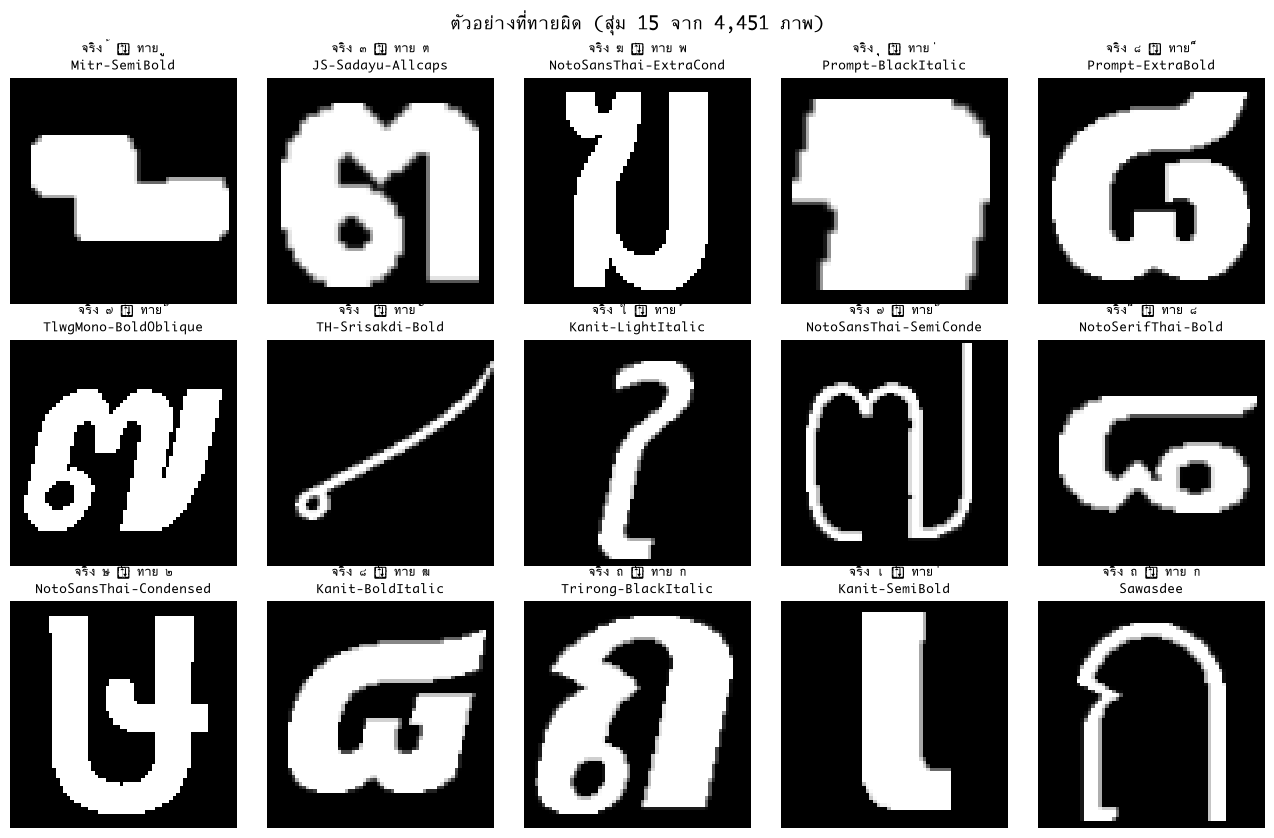

ไฟล์ที่บันทึก: ['misclassified_examples.png', 'results.csv', 'results_comparison.csv', 'summary_by_category.csv', 'summary_by_font.csv', 'summary_by_font_v3.csv']


In [15]:
# 2.9 บันทึกผล + กริดภาพที่ทายผิด
# results.csv = ผลรายภาพ (ไว้วิเคราะห์ต่อ) + สรุปอีก 2 ไฟล์
with open(RESULT_DIR / "results.csv", "w", newline="", encoding="utf-8-sig") as fh:
    w = csv.writer(fh)
    w.writerow(["filepath", "category", "font_name", "true_char", "pred_char", "true_idx", "pred_idx", "correct"])
    for r, yt, yp in zip(test_rows, y_true, y_pred):
        w.writerow([r["filepath"], r["category"], r["font_name"], r["char"], IDX_TO_CHAR[yp], int(yt), int(yp), int(yt == yp)])
for name, data in [("summary_by_category.csv", cat_rows), ("summary_by_font.csv", font_rows)]:
    with open(RESULT_DIR / name, "w", newline="", encoding="utf-8-sig") as fh:
        w = csv.DictWriter(fh, fieldnames=list(data[0])); w.writeheader(); w.writerows(data)

wrong = [(r, yt, yp) for r, yt, yp in zip(test_rows, y_true, y_pred) if yt != yp]
print(f"ทายผิด {len(wrong):,}/{len(test_rows):,} ภาพ ({len(wrong) / len(test_rows):.2%})")
pairs = Counter((IDX_TO_CHAR[yt], IDX_TO_CHAR[yp]) for _, yt, yp in wrong)
print("คู่ที่สับสนบ่อยสุด:", [f"{a}->{b} ({n})" for (a, b), n in pairs.most_common(10)])

random.seed(0)
show = random.sample(wrong, min(15, len(wrong)))
fig, axes = plt.subplots(3, 5, figsize=(13, 8.5))
for ax, (r, yt, yp) in zip(axes.ravel(), show):
    ax.imshow(preprocess(EXT_ROOT / r["filepath"]), cmap="gray"); ax.axis("off")
    ax.set_title(f"จริง {IDX_TO_CHAR[yt]} → ทาย {IDX_TO_CHAR[yp]}\n{r['font_name'][:22]}", fontsize=9)
for ax in axes.ravel()[len(show):]: ax.axis("off")
plt.suptitle(f"ตัวอย่างที่ทายผิด (สุ่ม {len(show)} จาก {len(wrong):,} ภาพ)", fontsize=13)
plt.tight_layout(); plt.savefig(RESULT_DIR / "misclassified_examples.png", dpi=130); plt.show()
print("ไฟล์ที่บันทึก:", sorted(p.name for p in RESULT_DIR.iterdir()))

## ขั้นที่ 3 — ทดสอบ v3 (`best_resnet50_v3.pt`) บนภาพชุดเดียวกัน
ใช้ `X_CACHE` ที่ preprocess ไว้แล้วจากขั้นที่ 2 (pipeline เหมือนกันทุกเวอร์ชัน จึงไม่ต้องทำซ้ำ)

In [16]:
# 3.1 โหลด checkpoint v3 + ตรวจว่า unified index ตรงกับ v1 ไหม
CKPT_V3 = PROJECT_ROOT / "checkpoints" / "best_resnet50_v3.pt"
ckpt3 = torch.load(CKPT_V3, map_location=device)
IDX_TO_CHAR_V3 = ckpt3["idx_to_char"]
CHAR_TO_IDX_V3 = {ch: i for i, ch in enumerate(IDX_TO_CHAR_V3)}

same_mapping = IDX_TO_CHAR_V3 == IDX_TO_CHAR
print(f"v3 checkpoint: phase {ckpt3['phase']} epoch {ckpt3['epoch']} · val macro F1 {ckpt3['val_f1']:.4f}")
print(f"คลาส {ckpt3['num_classes']} · target {ckpt3['target']} · input {ckpt3['input_size']} · "
      f"normalize ({ckpt3['gray_mean']}, {ckpt3['gray_std']})")
print(f"idx_to_char ตรงกับ v1 ทุกตำแหน่ง: {same_mapping}")
if not same_mapping:
    diff = [(i, a, b) for i, (a, b) in enumerate(zip(IDX_TO_CHAR, IDX_TO_CHAR_V3)) if a != b]
    print("  ตำแหน่งที่ต่าง:", diff[:10])
assert ckpt3["target"] == TARGET and ckpt3["gray_mean"] == GRAY_MEAN and ckpt3["gray_std"] == GRAY_STD, \
    "preprocess/normalize ของ v3 ไม่ตรงกับ v1 — ใช้ X_CACHE ร่วมกันไม่ได้"

# label ของภาพทดสอบในระบบ index ของ v3 (ถ้า mapping ตรงกันก็เท่ากับของเดิม)
y_true_v3 = np.array([CHAR_TO_IDX_V3[r["char"]] for r in test_rows])
test_classes_v3 = sorted(set(y_true_v3.tolist()))
print(f"label ของ v3: {len(test_classes_v3)} คลาส · เหมือน v1: {bool((y_true_v3 == y_true).all())}")

v3 checkpoint: phase 2 epoch 11 · val macro F1 0.9632
คลาส 81 · target 64 · input 128 · normalize (0.449, 0.226)
idx_to_char ตรงกับ v1 ทุกตำแหน่ง: True
label ของ v3: 78 คลาส · เหมือน v1: True


In [17]:
# 3.2 Inference ด้วย v3 บน X_CACHE (ไม่ preprocess ใหม่)
model_v3 = ThaiHCRNet(ckpt3["num_classes"], input_size=ckpt3["input_size"]).to(device)
model_v3.load_state_dict(ckpt3["model_state"], strict=True)
model_v3.eval()

def predict_from_cache(net, batch=256):
    out = []
    with torch.no_grad():
        for s0 in range(0, len(X_CACHE), batch):
            x = torch.from_numpy(X_CACHE[s0:s0 + batch]).unsqueeze(1).float() / 255.0
            x = ((x - GRAY_MEAN) / GRAY_STD).to(device)
            with torch.autocast(device_type=device, dtype=torch.bfloat16, enabled=True):
                out.append(net(x).argmax(1).cpu())
    return torch.cat(out).numpy()

t0 = time.perf_counter()
y_pred_v3 = predict_from_cache(model_v3)
print(f"v3 ทำนาย {len(y_pred_v3):,} ภาพ ใน {time.perf_counter() - t0:.0f}s (ไม่ต้อง preprocess ใหม่)")

# เช็คว่า cache ใช้ได้จริง: รัน v1 ซ้ำจาก cache ต้องได้ผลเท่าเดิมทุกภาพ
y_pred_v1_cache = predict_from_cache(model)
print(f"ตรวจ cache: v1 จาก cache ตรงกับผลเดิม {float((y_pred_v1_cache == y_pred).mean()):.4%}")

v3 ทำนาย 31,668 ภาพ ใน 83s (ไม่ต้อง preprocess ใหม่)
ตรวจ cache: v1 จาก cache ตรงกับผลเดิม 100.0000%


In [18]:
# 3.3 ผลของ v3 — ภาพรวม / แยกหมวด / แยกฟอนต์
acc_v3 = float((y_true_v3 == y_pred_v3).mean())
f1_v3  = f1_score(y_true_v3, y_pred_v3, average="macro", labels=test_classes_v3, zero_division=0)
print(f"v3 บน PrintAksorn: accuracy {acc_v3:.4f} · macro F1 {f1_v3:.4f}  ({len(y_true_v3):,} ภาพ · {len(test_classes_v3)} คลาส)\n")

cat_rows_v3 = []
for cat in ["consonants", "vowels", "tone_marks", "digits"]:
    m = cat_of == cat
    yt, yp = y_true_v3[m], y_pred_v3[m]
    present = sorted(set(yt.tolist()))
    cat_rows_v3.append({"category": cat, "n_images": int(m.sum()), "n_classes": len(present),
                        "accuracy": round(float((yt == yp).mean()), 4),
                        "macro_f1": round(f1_score(yt, yp, average="macro", labels=present, zero_division=0), 4)})
cat_rows_v3.append({"category": "ALL", "n_images": len(y_true_v3), "n_classes": len(test_classes_v3),
                    "accuracy": round(acc_v3, 4), "macro_f1": round(f1_v3, 4)})

v1_cat = {r["category"]: r for r in cat_rows}
print(f"{'หมวด':<16}{'v1 acc':>9}{'v3 acc':>9}{'Δacc':>9}{'v1 F1':>9}{'v3 F1':>9}{'ΔF1':>9}")
for r in cat_rows_v3:
    a = v1_cat[r["category"]]
    print(f"{r['category']:<16}{a['accuracy']:>9.4f}{r['accuracy']:>9.4f}{r['accuracy'] - a['accuracy']:>+9.4f}"
          f"{a['macro_f1']:>9.4f}{r['macro_f1']:>9.4f}{r['macro_f1'] - a['macro_f1']:>+9.4f}")

font_rows_v3 = []
for fname in sorted(set(font_of)):
    m = font_of == fname
    font_rows_v3.append({"font_name": fname, "n_images": int(m.sum()),
                         "accuracy": round(float((y_true_v3[m] == y_pred_v3[m]).mean()), 4)})
font_rows_v3.sort(key=lambda r: r["accuracy"])
accs3 = np.array([r["accuracy"] for r in font_rows_v3])
print(f"\nฟอนต์ {len(font_rows_v3)} แบบ · accuracy เฉลี่ย {accs3.mean():.4f} · median {np.median(accs3):.4f} · "
      f"ช่วง {accs3.min():.4f}–{accs3.max():.4f}")
print("\n10 ฟอนต์ที่แย่ที่สุด (v3)" + " " * 20 + "| 10 ฟอนต์ที่ดีที่สุด (v3)")
for lo, hi in zip(font_rows_v3[:10], font_rows_v3[::-1][:10]):
    print(f"  {lo['font_name'][:34]:<36}{lo['accuracy']:.4f} |   {hi['font_name'][:34]:<36}{hi['accuracy']:.4f}")

v3 บน PrintAksorn: accuracy 0.8603 · macro F1 0.8605  (31,668 ภาพ · 78 คลาส)

หมวด               v1 acc   v3 acc     Δacc    v1 F1    v3 F1      ΔF1
consonants         0.8949   0.8765  -0.0184   0.9033   0.8844  -0.0189
vowels             0.8254   0.8196  -0.0058   0.8607   0.8573  -0.0034
tone_marks         0.8788   0.8049  -0.0739   0.9272   0.8751  -0.0521
digits             0.7421   0.8808  +0.1387   0.7979   0.9236  +0.1257
ALL                0.8594   0.8603  +0.0009   0.8588   0.8605  +0.0017

ฟอนต์ 406 แบบ · accuracy เฉลี่ย 0.8603 · median 0.9359 · ช่วง 0.3333–1.0000

10 ฟอนต์ที่แย่ที่สุด (v3)                    | 10 ฟอนต์ที่ดีที่สุด (v3)
  Kanit-Black                         0.3333 |   TH-Chakra-Petch-Regular             1.0000
  Kanit-BlackItalic                   0.3718 |   JS-Saowapark-Normal                 1.0000
  Kanit-ExtraBold                     0.3846 |   JS-Pisit-Normal                     1.0000
  Kanit-Bold                          0.3974 |   TH-Sarabun-New-Regula

In [19]:
# 3.4 ตารางเทียบ v1 vs v3 + gap ระหว่าง "ตัวพิมพ์ที่เคยเห็น (D1)" กับ "ตัวพิมพ์ฟอนต์ใหม่ (PrintAksorn)"
D1_F1 = {"v1": 0.9332, "v3": 0.9209}          # macro F1 บน validation เฉพาะ D1 ที่วัดไว้ก่อนหน้า
D1_ACC = {"v1": 0.9897, "v3": 0.9855}
VAL_ALL = {"v1": (0.9715, 0.9671), "v3": (0.9676, 0.9632)}
res = {"v1": (acc, f1), "v3": (acc_v3, f1_v3)}

print(f"{'':<36}{'v1':>12}{'v3':>12}{'v3 − v1':>12}")
def line(name, a, b): print(f"{name:<36}{a:>12.4f}{b:>12.4f}{b - a:>+12.4f}")
line("PrintAksorn accuracy (78 คลาส)", res["v1"][0], res["v3"][0])
line("PrintAksorn macro F1", res["v1"][1], res["v3"][1])
print()
line("val ทั้งหมด accuracy", *[VAL_ALL[v][0] for v in ("v1", "v3")])
line("val ทั้งหมด macro F1",  *[VAL_ALL[v][1] for v in ("v1", "v3")])
line("val เฉพาะ D1 accuracy", D1_ACC["v1"], D1_ACC["v3"])
line("val เฉพาะ D1 macro F1", D1_F1["v1"], D1_F1["v3"])
print()
print("gap = ตัวพิมพ์ที่เคยเห็น (D1) − ตัวพิมพ์ฟอนต์ใหม่ (PrintAksorn) : ยิ่งน้อย ยิ่ง generalize ดี")
for v in ("v1", "v3"):
    print(f"  {v}: accuracy gap {D1_ACC[v] - res[v][0]:+.4f} · macro F1 gap {D1_F1[v] - res[v][1]:+.4f}")

comp = []
for v, (a_, f_) in res.items():
    comp.append({"model": v, "checkpoint": (CKPT_PATH if v == "v1" else CKPT_V3).name,
                 "printaksorn_n_images": len(y_true), "printaksorn_n_classes": len(test_classes),
                 "printaksorn_accuracy": round(a_, 4), "printaksorn_macro_f1": round(f_, 4),
                 "val_all_accuracy": VAL_ALL[v][0], "val_all_macro_f1": VAL_ALL[v][1],
                 "val_D1_accuracy": D1_ACC[v], "val_D1_macro_f1": D1_F1[v],
                 "gap_accuracy_D1_minus_printaksorn": round(D1_ACC[v] - a_, 4),
                 "gap_macro_f1_D1_minus_printaksorn": round(D1_F1[v] - f_, 4)})
    for r in (cat_rows if v == "v1" else cat_rows_v3):
        comp[-1][f"{r['category']}_accuracy"] = r["accuracy"]
        comp[-1][f"{r['category']}_macro_f1"] = r["macro_f1"]

with open(RESULT_DIR / "results_comparison.csv", "w", newline="", encoding="utf-8-sig") as fh:
    w = csv.DictWriter(fh, fieldnames=list(comp[0])); w.writeheader(); w.writerows(comp)
with open(RESULT_DIR / "summary_by_font_v3.csv", "w", newline="", encoding="utf-8-sig") as fh:
    w = csv.DictWriter(fh, fieldnames=list(font_rows_v3[0])); w.writeheader(); w.writerows(font_rows_v3)

wrong_v3 = int((y_true_v3 != y_pred_v3).sum())
pairs_v3 = Counter((IDX_TO_CHAR_V3[t], IDX_TO_CHAR_V3[p]) for t, p in zip(y_true_v3, y_pred_v3) if t != p)
print(f"\nv3 ทายผิด {wrong_v3:,}/{len(y_true_v3):,} ({wrong_v3 / len(y_true_v3):.2%}) · v1 ทายผิด {len(wrong):,} ({len(wrong) / len(test_rows):.2%})")
print("คู่ที่ v3 สับสนบ่อยสุด:", [f"{a}->{b} ({n})" for (a, b), n in pairs_v3.most_common(10)])
print("ไฟล์:", sorted(p.name for p in RESULT_DIR.iterdir()))

                                              v1          v3     v3 − v1
PrintAksorn accuracy (78 คลาส)            0.8594      0.8603     +0.0008
PrintAksorn macro F1                      0.8588      0.8605     +0.0017

val ทั้งหมด accuracy                      0.9715      0.9676     -0.0039
val ทั้งหมด macro F1                      0.9671      0.9632     -0.0039
val เฉพาะ D1 accuracy                     0.9897      0.9855     -0.0042
val เฉพาะ D1 macro F1                     0.9332      0.9209     -0.0123

gap = ตัวพิมพ์ที่เคยเห็น (D1) − ตัวพิมพ์ฟอนต์ใหม่ (PrintAksorn) : ยิ่งน้อย ยิ่ง generalize ดี
  v1: accuracy gap +0.1303 · macro F1 gap +0.0744
  v3: accuracy gap +0.1252 · macro F1 gap +0.0604

v3 ทายผิด 4,425/31,668 (13.97%) · v1 ทายผิด 4,451 (14.06%)
คู่ที่ v3 สับสนบ่อยสุด: ['ๅ->า (219)', '็->๘ (205)', '๊->๗ (185)', 'ฃ->ข (156)', '๓->ต (151)', '๘->็ (102)', 'ฑ->ท (100)', '๗->๊ (96)', 'จ->อ (89)', 'เ->่ (79)']
ไฟล์: ['misclassified_examples.png', 'results.csv', 'results_comparison

## ขั้นที่ 4 — Ensemble (v1 + v3) บนภาพชุดเดียวกัน
เฉลี่ย softmax ของสองโมเดลแล้วค่อย argmax · ใช้ `X_CACHE` เดิม ไม่ preprocess ใหม่
เป้าหมาย: ตัดสินใจว่าจะใช้ ensemble ใน `inference_testset.ipynb` วันสอบหรือไม่

In [20]:
# 4.1 เฉลี่ย softmax ของ v1 + v3
def proba_from_cache(net, batch=256):
    out = []
    with torch.no_grad():
        for s0 in range(0, len(X_CACHE), batch):
            x = torch.from_numpy(X_CACHE[s0:s0 + batch]).unsqueeze(1).float() / 255.0
            x = ((x - GRAY_MEAN) / GRAY_STD).to(device)
            with torch.autocast(device_type=device, dtype=torch.bfloat16, enabled=True):
                out.append(net(x).float().softmax(1).cpu())
    return torch.cat(out)

t0 = time.perf_counter()
P1, P3 = proba_from_cache(model), proba_from_cache(model_v3)
P_ens  = (P1 + P3) / 2
y_pred_ens = P_ens.argmax(1).numpy()
print(f"คำนวณ softmax ทั้งสองโมเดล + เฉลี่ย ใน {time.perf_counter() - t0:.0f}s")

acc_ens = float((y_true == y_pred_ens).mean())
f1_ens  = f1_score(y_true, y_pred_ens, average="macro", labels=test_classes, zero_division=0)
agree = float((y_pred == y_pred_v3).mean())
print(f"สองโมเดลทายตรงกัน {agree:.2%} ของภาพ")
print(f"ensemble: accuracy {acc_ens:.4f} · macro F1 {f1_ens:.4f}")

คำนวณ softmax ทั้งสองโมเดล + เฉลี่ย ใน 188s
สองโมเดลทายตรงกัน 88.50% ของภาพ
ensemble: accuracy 0.8686 · macro F1 0.8696


In [21]:
# 4.2 เทียบ 3 แบบ: ภาพรวม + แยกหมวด
def metrics(yp, mask=None):
    m = np.ones(len(y_true), bool) if mask is None else mask
    yt, yq = y_true[m], yp[m]
    present = sorted(set(yt.tolist()))
    return float((yt == yq).mean()), f1_score(yt, yq, average="macro", labels=present, zero_division=0)

print(f"{'':<16}{'v1 acc':>9}{'v3 acc':>9}{'ens acc':>10}{'v1 F1':>9}{'v3 F1':>9}{'ens F1':>10}{'ens−best':>10}")
rows_ens = []
for cat in ["consonants", "vowels", "tone_marks", "digits", "ALL"]:
    m = None if cat == "ALL" else (cat_of == cat)
    (a1, g1), (a3, g3), (ae, ge) = metrics(y_pred, m), metrics(y_pred_v3, m), metrics(y_pred_ens, m)
    rows_ens.append({"category": cat, "n_images": int(len(y_true) if m is None else m.sum()),
                     "v1_accuracy": round(a1, 4), "v3_accuracy": round(a3, 4), "ens_accuracy": round(ae, 4),
                     "v1_macro_f1": round(g1, 4), "v3_macro_f1": round(g3, 4), "ens_macro_f1": round(ge, 4)})
    print(f"{cat:<16}{a1:>9.4f}{a3:>9.4f}{ae:>10.4f}{g1:>9.4f}{g3:>9.4f}{ge:>10.4f}{ae - max(a1, a3):>+10.4f}")

                   v1 acc   v3 acc   ens acc    v1 F1    v3 F1    ens F1  ens−best
consonants         0.8949   0.8765    0.8933   0.9033   0.8844    0.9018   -0.0016
vowels             0.8254   0.8196    0.8299   0.8607   0.8573    0.8652   +0.0045
tone_marks         0.8788   0.8049    0.8581   0.9272   0.8751    0.9150   -0.0207
digits             0.7421   0.8808    0.8232   0.7979   0.9236    0.8760   -0.0576
ALL                0.8594   0.8603    0.8686   0.8588   0.8605    0.8696   +0.0084


In [22]:
# 4.3 แยกตามฟอนต์ + ฟอนต์ที่แย่ที่สุด (จุดที่ ensemble ควรช่วย)
font_acc = {}
for fname in sorted(set(font_of)):
    m = font_of == fname
    font_acc[fname] = (float((y_true[m] == y_pred[m]).mean()),
                       float((y_true[m] == y_pred_v3[m]).mean()),
                       float((y_true[m] == y_pred_ens[m]).mean()))
a1s, a3s, aes = (np.array([v[i] for v in font_acc.values()]) for i in range(3))
print(f"{'':<12}{'เฉลี่ย':>10}{'median':>10}{'ต่ำสุด':>10}{'ฟอนต์ที่ acc < 0.7':>22}")
for name, arr in [("v1", a1s), ("v3", a3s), ("ensemble", aes)]:
    print(f"{name:<12}{arr.mean():>10.4f}{np.median(arr):>10.4f}{arr.min():>10.4f}{int((arr < 0.7).sum()):>22}")

worst = sorted(font_acc.items(), key=lambda kv: kv[1][2])[:10]
print(f"\n10 ฟอนต์ที่ ensemble ยังแย่สุด    {'v1':>8}{'v3':>8}{'ens':>8}")
for f, (a1, a3, ae) in worst:
    print(f"  {f[:30]:<32}{a1:>8.4f}{a3:>8.4f}{ae:>8.4f}")

                เฉลี่ย    median    ต่ำสุด    ฟอนต์ที่ acc < 0.7
v1              0.8594    0.9231    0.3846                    72
v3              0.8603    0.9359    0.3333                    83
ensemble        0.8686    0.9359    0.3846                    74

10 ฟอนต์ที่ ensemble ยังแย่สุด          v1      v3     ens
  Kanit-Black                       0.3846  0.3333  0.3846
  Kanit-BlackItalic                 0.3974  0.3718  0.4103
  Kanit-ExtraBold                   0.4744  0.3846  0.4231
  Kanit-Bold                        0.4744  0.3974  0.4359
  Mitr-Bold                         0.4744  0.4359  0.4359
  JS-Thanaporn-Normal               0.5128  0.4872  0.4615
  JS-Oobboon-Normal                 0.4231  0.5128  0.4744
  Kanit-ExtraBoldItalic             0.4744  0.4103  0.4744
  Prompt-BlackItalic                0.4615  0.5000  0.5000
  Kanit-BoldItalic                  0.5000  0.4615  0.5128


In [23]:
# 4.4 สรุป + บันทึกไฟล์
with open(RESULT_DIR / "results_ensemble.csv", "w", newline="", encoding="utf-8-sig") as fh:
    w = csv.DictWriter(fh, fieldnames=list(rows_ens[0])); w.writeheader(); w.writerows(rows_ens)
with open(RESULT_DIR / "summary_by_font_ensemble.csv", "w", newline="", encoding="utf-8-sig") as fh:
    w = csv.writer(fh); w.writerow(["font_name", "v1_accuracy", "v3_accuracy", "ens_accuracy"])
    for f, (a1, a3, ae) in sorted(font_acc.items(), key=lambda kv: kv[1][2]):
        w.writerow([f, round(a1, 4), round(a3, 4), round(ae, 4)])

print(f"{'':<24}{'accuracy':>11}{'macro F1':>11}")
for name, a_, f_ in [("v1", acc, f1), ("v3", acc_v3, f1_v3), ("ensemble", acc_ens, f1_ens)]:
    print(f"{name:<24}{a_:>11.4f}{f_:>11.4f}")
print(f"\nensemble − v1: accuracy {acc_ens - acc:+.4f} · macro F1 {f1_ens - f1:+.4f}")
print(f"ensemble − v3: accuracy {acc_ens - acc_v3:+.4f} · macro F1 {f1_ens - f1_v3:+.4f}")
gain = acc_ens - max(acc, acc_v3)
print(f"\nสรุป: ensemble {'ดีกว่า' if gain > 0 else 'ไม่ดีกว่า'}โมเดลเดี่ยวที่ดีที่สุด {abs(gain):.4f} "
      f"({abs(gain) * len(y_true):.0f} ภาพ จาก {len(y_true):,})")
print("ไฟล์:", sorted(p.name for p in RESULT_DIR.iterdir()))

                           accuracy   macro F1
v1                           0.8594     0.8588
v3                           0.8603     0.8605
ensemble                     0.8686     0.8696

ensemble − v1: accuracy +0.0092 · macro F1 +0.0109
ensemble − v3: accuracy +0.0084 · macro F1 +0.0092

สรุป: ensemble ดีกว่าโมเดลเดี่ยวที่ดีที่สุด 0.0084 (265 ภาพ จาก 31,668)
ไฟล์: ['misclassified_examples.png', 'results.csv', 'results_comparison.csv', 'results_ensemble.csv', 'summary_by_category.csv', 'summary_by_font.csv', 'summary_by_font_ensemble.csv', 'summary_by_font_v3.csv']
